# 03 — Budgeted Equity Curve & Hypervolume 2D/3D

Thực hiện **Section 6.2** (budgeted equity curve — figure quan trọng nhất bài)
và **Section 6.3** (2D Hypervolume distance–Gini với ràng buộc maxTime).

Input: `artifacts/solutions_clean.csv`, `artifacts/fleet_targets.csv`.
Output: `artifacts/budget_curve.csv`, `artifacts/hv2d_results.csv`, hình vẽ.


In [1]:
# ==== CẤU HÌNH ĐƯỜNG DẪN (chỉnh lại cho đúng máy của bạn) ====
import sys, os
sys.path.append(os.path.abspath("."))  # để import evrp_analysis_utils.py cùng thư mục

FULL_DIR  = "benchmark/full"     # thư mục kết quả bản đầy đủ (equity-aware)
NOEQ_DIR  = "benchmark/no-EQ"    # thư mục kết quả bản loại equity guidance
ARTIFACT_DIR = "artifacts"       # nơi lưu các bảng trung gian (csv) giữa các notebook
os.makedirs(ARTIFACT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import evrp_analysis_utils as utils

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [2]:
import matplotlib.pyplot as plt

solutions_clean = pd.read_csv(f"{ARTIFACT_DIR}/solutions_clean.csv")
fleet_targets = pd.read_csv(f"{ARTIFACT_DIR}/fleet_targets.csv")
merged = solutions_clean.merge(fleet_targets[["Instance", "Z1_common"]], on="Instance", how="left")
merged = merged.dropna(subset=["Z1_common"])
print(f"{merged['Instance'].nunique()} instances có common fleet target")


91 instances có common fleet target


## 3.1. Reference distance $D_i^{ref}$ và reference maxTime $H_i^{ref}$ mỗi instance

In [3]:
ref_rows = []
for instance, g in merged.groupby("Instance"):
    z1c = g["Z1_common"].iloc[0]
    sub = g[g["Z1"] == z1c]
    if sub.empty:
        continue
    d_ref = sub["Z2"].min()
    h_ref = sub["Z4"].min() if "Z4" in sub.columns else np.nan
    ref_rows.append({"Instance": instance, "Z1_common": z1c, "D_ref": d_ref, "H_ref": h_ref})

refs = pd.DataFrame(ref_rows)
refs.to_csv(f"{ARTIFACT_DIR}/budget_references.csv", index=False)
refs.head()


,Instance,Z1_common,D_ref,H_ref
0,c101C10,3.0,388.2454,1162.8058
1,c101C5,2.0,257.7475,872.0789
2,c101_21,12.0,1043.4548,1174.5529
3,c102_21,11.0,1037.1225,1174.5529
4,c103C15,3.0,374.4278,1162.8058


## 3.2. Budgeted equity curve mỗi instance x variant

In [4]:
curve_rows = []
for (variant, instance), g in merged.groupby(["Variant", "Instance"]):
    ref = refs.loc[refs["Instance"] == instance]
    if ref.empty:
        continue
    z1c, d_ref, h_ref = ref.iloc[0][["Z1_common", "D_ref", "H_ref"]]
    curve = utils.budgeted_equity_curve(g, int(z1c), d_ref, h_ref)
    curve["Variant"] = variant
    curve["Instance"] = instance
    curve_rows.append(curve)

budget_curve = pd.concat(curve_rows, ignore_index=True) if curve_rows else pd.DataFrame()
budget_curve.to_csv(f"{ARTIFACT_DIR}/budget_curve.csv", index=False)
print(f"{len(budget_curve)} dòng budget curve (instance x variant x eta_D x eta_H)")
budget_curve.head(10)


1820 dòng budget curve (instance x variant x eta_D x eta_H)


,eta_D,eta_H,d_cap,h_cap,best_Gini,n_feasible,Variant,Instance
0,0.00,0.00,388.245400,1162.80580,0.1195,8,FULL,c101C10
1,0.01,0.00,392.127854,1162.80580,0.1104,22,FULL,c101C10
2,0.03,0.00,399.892762,1162.80580,0.1078,25,FULL,c101C10
3,0.05,0.00,407.657670,1162.80580,0.0130,46,FULL,c101C10
4,0.10,0.00,427.069940,1162.80580,0.0043,63,FULL,c101C10
5,0.00,0.05,388.245400,1220.94609,0.1195,8,FULL,c101C10
6,0.01,0.05,392.127854,1220.94609,0.1104,22,FULL,c101C10
7,0.03,0.05,399.892762,1220.94609,0.1078,25,FULL,c101C10
8,0.05,0.05,407.657670,1220.94609,0.0130,48,FULL,c101C10
9,0.10,0.05,427.069940,1220.94609,0.0043,65,FULL,c101C10


## 3.3. Figure chính: Gini vs allowable distance premium (trung bình qua instance, eta_H=0.05)

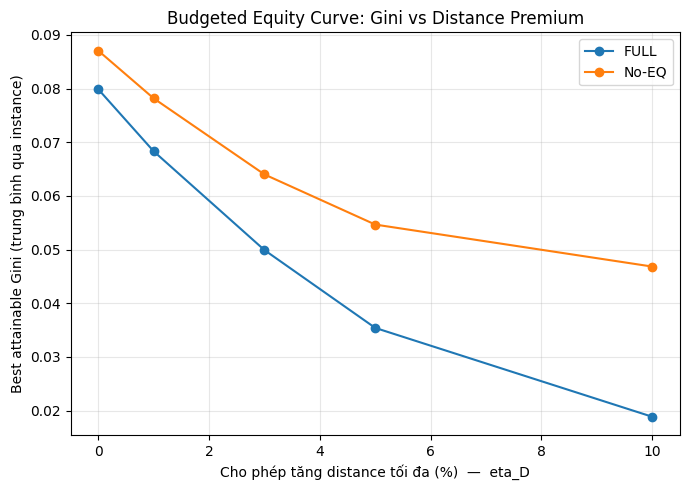

In [5]:
plot_df = budget_curve[budget_curve["eta_H"] == 0.05]
agg = plot_df.groupby(["Variant", "eta_D"])["best_Gini"].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
for variant, g in agg.groupby("Variant"):
    ax.plot(g["eta_D"] * 100, g["best_Gini"], marker="o", label=variant)
ax.set_xlabel("Cho phép tăng distance tối đa (%)  —  eta_D")
ax.set_ylabel("Best attainable Gini (trung bình qua instance)")
ax.set_title("Budgeted Equity Curve: Gini vs Distance Premium")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/fig_budget_equity_curve.png", dpi=150)
plt.show()


## 3.4. Hypervolume 2D (Z2, Z3) tại common fleet target, ràng buộc maxTime (Section 6.3)

In [6]:
ETA_H = 0.05  # ràng buộc maxTime nới lỏng dùng cho HV2D

hv_rows = []
for instance, g_inst in merged.groupby("Instance"):
    ref = refs.loc[refs["Instance"] == instance]
    if ref.empty:
        continue
    z1c, h_ref = ref.iloc[0][["Z1_common", "H_ref"]]
    h_cap = h_ref * (1 + ETA_H) if not pd.isna(h_ref) else np.inf

    subset_cols = [c for c in ["Z2", "Z3"] if c in g_inst.columns]
    if len(subset_cols) < 2:
        continue

    pts_by_variant = {}
    for variant, gv in g_inst.groupby("Variant"):
        cond = gv["Z1"] == z1c
        if "Z4" in gv.columns:
            cond &= gv["Z4"] <= h_cap
        p = gv.loc[cond, subset_cols]
        if not p.empty:
            p = utils.nondominated_filter(p, subset_cols)
        pts_by_variant[variant] = p

    all_pts = pd.concat(pts_by_variant.values(), ignore_index=True) if pts_by_variant else pd.DataFrame()
    if all_pts.empty:
        continue
    ref_min, ref_max = all_pts.min(), all_pts.max()

    for variant, p in pts_by_variant.items():
        if p.empty:
            hv_rows.append({"Instance": instance, "Variant": variant, "HV2D": 0.0, "n_points": 0})
            continue
        norm, _, _ = utils.normalize_objectives(p, subset_cols, ref_min, ref_max)
        hv = utils.hypervolume_via_montecarlo(norm.to_numpy(), ref_point=np.array([1.05, 1.05]), n_samples=50_000)
        hv_rows.append({"Instance": instance, "Variant": variant, "HV2D": hv, "n_points": len(p)})

hv2d_results = pd.DataFrame(hv_rows)
hv2d_results.to_csv(f"{ARTIFACT_DIR}/hv2d_results.csv", index=False)
print(hv2d_results.groupby("Variant")["HV2D"].agg(["mean", "median", "std"]))
hv2d_results.head(10)


             mean    median       std
Variant                              
FULL     0.873357  0.871835  0.178594
No-EQ    0.541926  0.558041  0.331498


,Instance,Variant,HV2D,n_points
0,c101C10,FULL,0.770537,64
1,c101C10,No-EQ,0.535242,9
2,c101C5,FULL,0.871835,53
3,c101C5,No-EQ,0.051906,6
4,c101_21,FULL,0.965878,17
5,c101_21,No-EQ,0.452907,5
6,c102_21,FULL,0.866609,19
7,c102_21,No-EQ,0.599738,11
8,c103C15,FULL,0.978535,19
9,c103C15,No-EQ,0.339746,7


## 3.5. (Robustness) Hypervolume 3D (Z2, Z3, Z4)

In [7]:
hv3d_rows = []
subset_cols_3d = [c for c in ["Z2", "Z3", "Z4"] if c in merged.columns]
if len(subset_cols_3d) == 3:
    for instance, g_inst in merged.groupby("Instance"):
        z1c = g_inst["Z1_common"].iloc[0]
        pts_by_variant = {}
        for variant, gv in g_inst.groupby("Variant"):
            p = gv.loc[gv["Z1"] == z1c, subset_cols_3d]
            if not p.empty:
                p = utils.nondominated_filter(p, subset_cols_3d)
            pts_by_variant[variant] = p
        all_pts = pd.concat(pts_by_variant.values(), ignore_index=True) if pts_by_variant else pd.DataFrame()
        if all_pts.empty:
            continue
        ref_min, ref_max = all_pts.min(), all_pts.max()
        for variant, p in pts_by_variant.items():
            if p.empty:
                hv3d_rows.append({"Instance": instance, "Variant": variant, "HV3D": 0.0})
                continue
            norm, _, _ = utils.normalize_objectives(p, subset_cols_3d, ref_min, ref_max)
            hv = utils.hypervolume_via_montecarlo(
                norm.to_numpy(), ref_point=np.array([1.05, 1.05, 1.05]), n_samples=50_000)
            hv3d_rows.append({"Instance": instance, "Variant": variant, "HV3D": hv})

hv3d_results = pd.DataFrame(hv3d_rows)
hv3d_results.to_csv(f"{ARTIFACT_DIR}/hv3d_results.csv", index=False)
hv3d_results.groupby("Variant")["HV3D"].mean() if not hv3d_results.empty else "Thiếu cột Z3/Z4 cho HV3D"


Variant
FULL     0.813434
No-EQ    0.549333
Name: HV3D, dtype: float64